# brownian_map testing notebook

Procedural map generation from 2D Brownian-style random surfaces. The
pipeline, module by module:

| Module | Role |
| --- | --- |
| [`surface.py`](brownian_map/surface.py) | Generates the raw heightmap: floats in `[-1, 1]`, shape `(dim, dim)`, wrapping at the edges (a torus). |
| [`palette.py`](brownian_map/palette.py) | Loads the RGB colour ramp and quantizes the raw heightmap into palette-index bins. |
| [`postprocess.py`](brownian_map/postprocess.py) | Cleans single-cell speckle noise, extracts elevation isocurves. |
| [`render.py`](brownian_map/render.py) | Matplotlib rendering of the surface + isocurves. |
| [`cli.py`](brownian_map/cli.py) | Wires all of the above into one `generate_map()` call and a `python -m brownian_map.cli` entry point. |
| [`rivers.py`](brownian_map/rivers.py) | Hill-climbing path tracing. **Not part of the pipeline** — see section 4. |

Each section below runs one stage in isolation so you can see its effect,
before section 5 runs the same thing end-to-end via `cli.generate_map`.

## Parameter glossary

| Parameter | Where | Meaning |
| --- | --- | --- |
| `dim` | `surface.*` | Grid side length; the map is `dim x dim` cells. |
| `sparks` | `surface.generate_*_spark_surface` | Number of seed points/steps laid down before the neighbour-averaging fill runs. In `generate_brownian_spark_surface` these are steps of one connected random walk, not independent points. |
| `n_walks` | `surface.generate_multi_spark_surface` | How many independent Brownian-walk seed surfaces to combine (by cell-wise max) into one. See section 1. |
| `step` | `surface.*` | Per-cell jitter added during the fill: `clamp(neighbour_average + uniform(-step, step))`. Higher = noisier, more jagged terrain, and more land. |
| `n_bins` | `palette.normalize_surface` | How many palette indices the `[-1, 1]` surface is quantized into. Land gets `n_bins - 2` bins. |
| `low_bins` | `palette.normalize_surface` | How many of the palette indices are reserved for sea depth (default 10); land starts at index `low_bins`. |
| `n_levels` | `postprocess.compute_isocurves` | How many elevation levels (palette indices) to trace contours for. |
| `seed` | `random.seed()` | Fixes Python's RNG for reproducible output. |

## About `rivers.py`

Not used anywhere: not by this notebook, and no longer by
`cli.generate_map` either. Both the uphill (`generate_rivers`) and
downhill/mountain-to-sea (`generate_rivers_downhill`) tracers hill-climb
over a *static* surface, and both cap out at short, unconvincing paths —
see `rivers.py`'s module docstring for why, and for a sketched-out idea
(not implemented) of tracing a river as a feedback process that excavates
the terrain as it flows, instead.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import random

import numpy as np
from matplotlib import pyplot as plt

# requires the package installed editable: pip install -e ".[notebook]"
from brownian_map import palette, postprocess, render, surface
from brownian_map.cli import generate_map

SEED = 0
DIM = 150  # small for fast iteration; bump to 300+ for final-looking maps


## 1. Raw surfaces

Two generator families (see `surface.py`'s module docstring):

- **Row-based** (`generate_row_surface`): each row is a bounded random walk
  derived from the previous row. `RowOrder` controls the write direction —
  `FORWARD`/`BACKWARD` write every row the same way and leave a visible
  directional drift; `ALTERNATE` (boustrophedon) cancels it; `RANDOM` avoids
  it too but is noisier.
- **Spark-propagation** (`generate_spark_surface`,
  `generate_brownian_spark_surface`): a few seed cells are placed, then
  every other cell is filled by averaging its already-filled neighbours plus
  jitter, in random fill order. `generate_brownian_spark_surface`'s seeds
  are steps of one connected random walk rather than independent points,
  which gives more contiguous coastlines.

Both wrap at the edges (a torus), so they tile seamlessly.

**Caveat at large `dim`:** a `generate_brownian_spark_surface` seed walk is
a short, localized curve. That's fine relative to a small grid, but on a
much bigger one the whole map ends up as *one* basin radiating outward from
it — visually a single "starburst" centred on whichever point is farthest
from the walk. `generate_multi_spark_surface(dim, n_walks=...)` fixes this
by overlaying several independent walks via cell-wise `max` (not average,
which just drags everything toward the shared seed value) — multiple
basins/coastlines instead of one. It's used in section 4's bigger terrain.

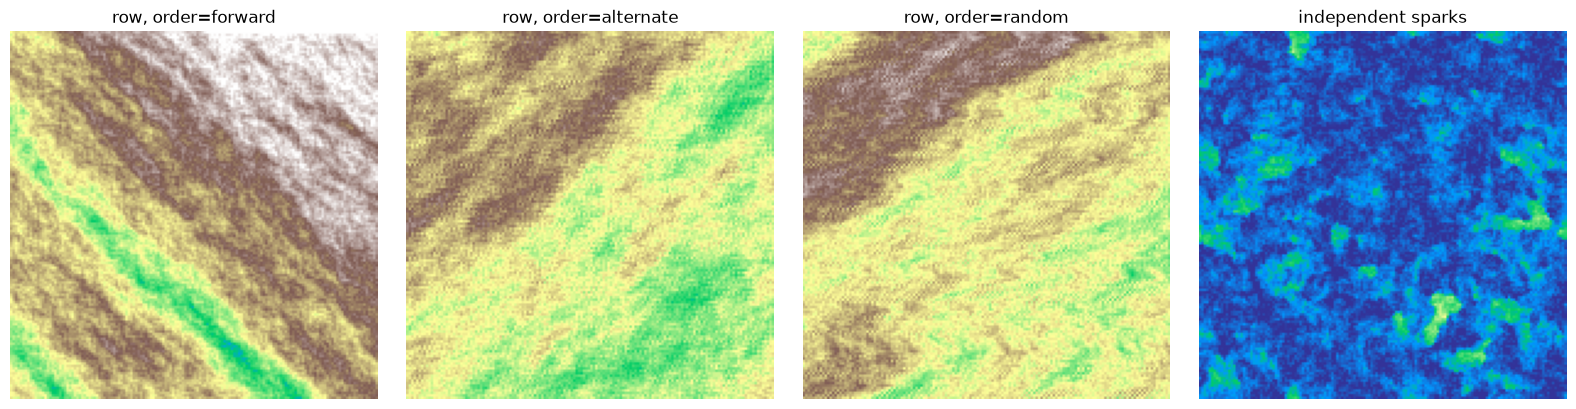

In [2]:
random.seed(SEED)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, order in zip(axes[:3], [surface.RowOrder.FORWARD, surface.RowOrder.ALTERNATE, surface.RowOrder.RANDOM]):
    srf = surface.generate_row_surface(DIM, step=0.1, order=order)
    ax.imshow(srf, cmap="terrain", vmin=-1, vmax=1)
    ax.set_title(f"row, order={order.value}")
    ax.set_axis_off()

srf_spark = surface.generate_spark_surface(DIM, sparks=20, step=0.1)
axes[3].imshow(srf_spark, cmap="terrain", vmin=-1, vmax=1)
axes[3].set_title("independent sparks")
axes[3].set_axis_off()

fig.tight_layout()

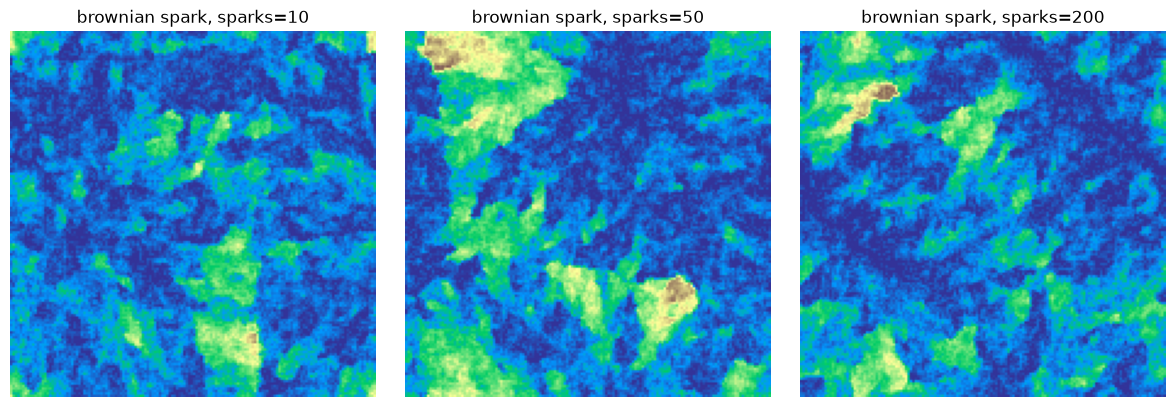

In [3]:
random.seed(SEED)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, sparks in zip(axes, [10, 50, 200]):
    srf = surface.generate_brownian_spark_surface(DIM, sparks=sparks, step=0.1)
    ax.imshow(srf, cmap="terrain", vmin=-1, vmax=1)
    ax.set_title(f"brownian spark, sparks={sparks}")
    ax.set_axis_off()
fig.tight_layout()

# keep one around for the rest of the notebook
random.seed(SEED)
raw_surface = surface.generate_brownian_spark_surface(DIM, sparks=100, step=0.1)

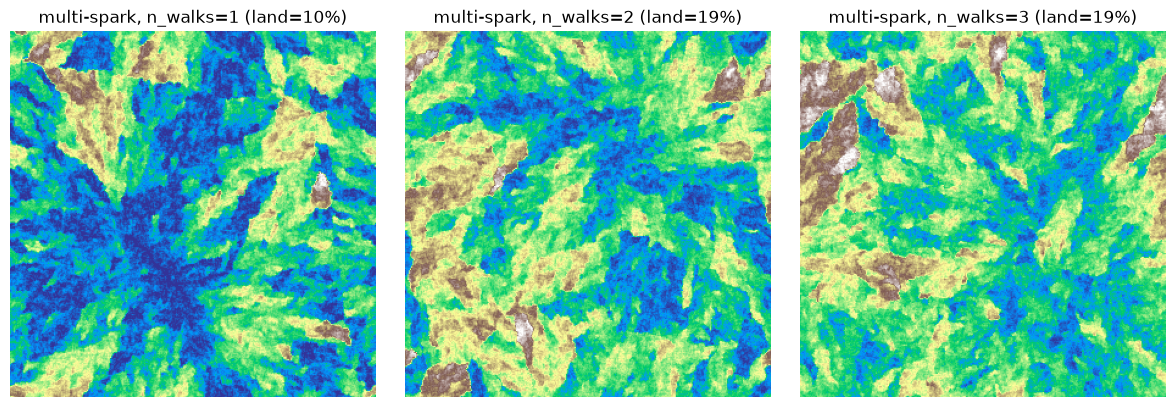

In [4]:
random.seed(SEED)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, n_walks in zip(axes, [1, 2, 3]):
    srf = surface.generate_multi_spark_surface(300, n_walks=n_walks, sparks=100, step=0.1)
    ax.imshow(srf, cmap="terrain", vmin=-1, vmax=1)
    ax.set_title(f"multi-spark, n_walks={n_walks} (land={100 * (srf > 0).mean():.0f}%)")
    ax.set_axis_off()
fig.tight_layout()
# n_walks=1 is exactly generate_brownian_spark_surface: note the single
# dominant basin. More walks break that up and raise land coverage.

## 2. Palette normalization

`palette.load_palette` reads the bundled `wiki-2.0.gpf` ramp (a 29-colour
bathymetric/hypsometric scale: deep sea to peaks) into an `(n, 3)` array of
floats in `[0, 1]`.

`palette.normalize_surface(surface, n_bins, low_bins)` then quantizes the
`[-1, 1]` heightmap into palette indices: values `<= 0` (sea) map onto
`[0, low_bins)`, values `> 0` (land) onto `[low_bins, low_bins + n_bins - 2)`.
The asymmetry mirrors the palette, which devotes more entries to land
elevation bands than to sea depth. `colorize` then just indexes the palette
with those integers to get an RGB image.

29 colours


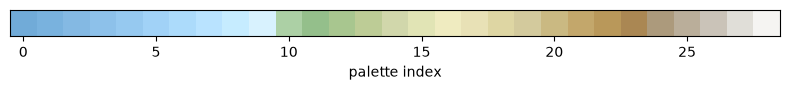

In [5]:
rgb_palette = palette.load_palette()
print(f"{len(rgb_palette)} colours")

fig, ax = plt.subplots(figsize=(8, 1))
ax.imshow([rgb_palette], aspect="auto")
ax.set_yticks([])
ax.set_xlabel("palette index")
fig.tight_layout()

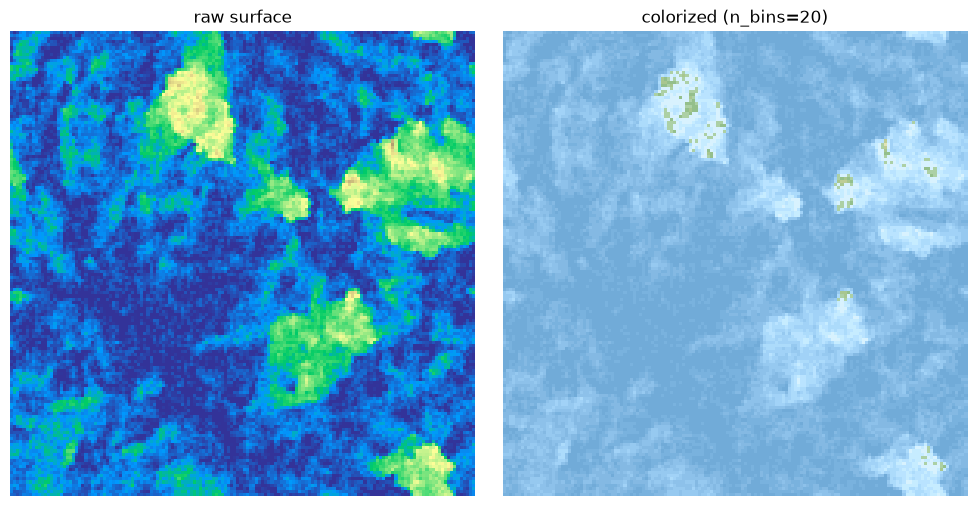

In [6]:
N_BINS = 20
normalized = palette.normalize_surface(raw_surface, n_bins=N_BINS)
colorized = palette.colorize(normalized, rgb_palette)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_surface, cmap="terrain", vmin=-1, vmax=1)
axes[0].set_title("raw surface")
axes[0].set_axis_off()
axes[1].imshow(colorized)
axes[1].set_title(f"colorized (n_bins={N_BINS})")
axes[1].set_axis_off()
fig.tight_layout()

## 3. Cleanup: `clean_isolated_points`

The spark fill's random cell-by-cell order can leave single-cell "speckle":
a cell whose value differs from all four of its (wrapping) neighbours.
`postprocess.clean_isolated_points` replaces each such cell with its most
common neighbour value. Below, highlight exactly which cells get
overwritten.

2623 / 22500 cells changed (11.66%)


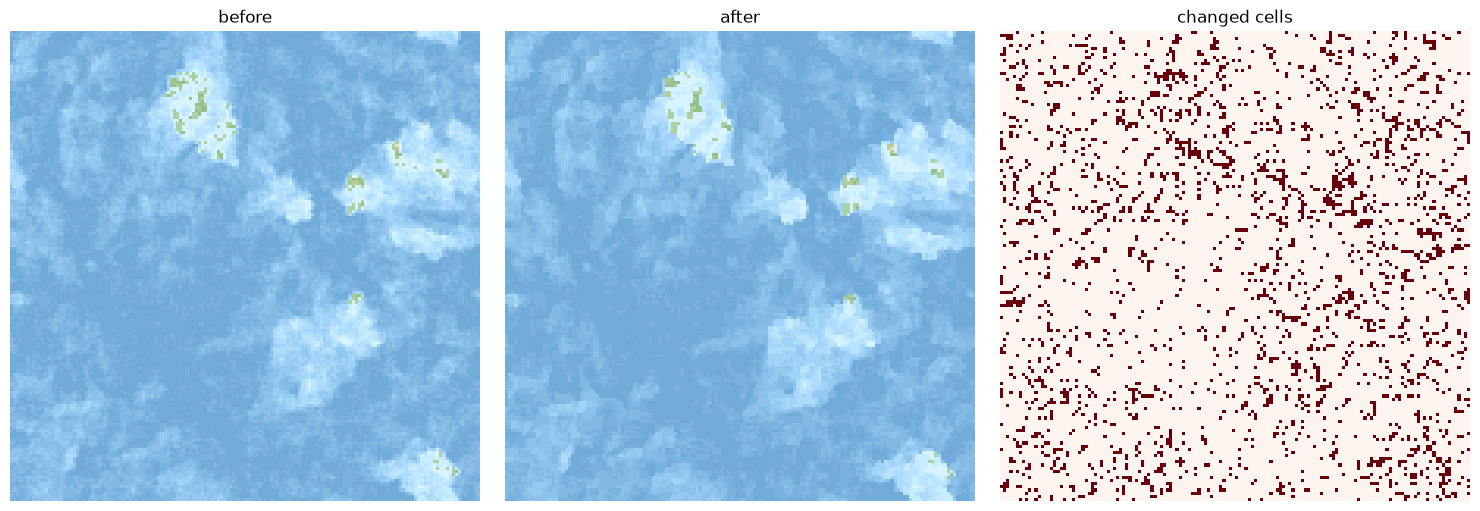

In [7]:
clean = postprocess.clean_isolated_points(normalized)
changed = clean != normalized
print(f"{changed.sum()} / {changed.size} cells changed ({changed.mean():.2%})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(palette.colorize(normalized, rgb_palette))
axes[0].set_title("before")
axes[0].set_axis_off()
axes[1].imshow(palette.colorize(clean, rgb_palette))
axes[1].set_title("after")
axes[1].set_axis_off()
axes[2].imshow(changed, cmap="Reds")
axes[2].set_title("changed cells")
axes[2].set_axis_off()
fig.tight_layout()

## 4. Isocurves

`postprocess.compute_isocurves(surface, n_levels)` runs
`skimage.measure.find_contours` at each palette-index level `0..n_levels-1`,
returning one list of contours per level — these are the thin elevation
lines `render.render_surface` overlays.

River generation (`rivers.py`) is deliberately not part of the pipeline.
Hill-climbing over the quantized palette-index array (uphill from a low
point, or the downhill mountain-to-sea variant also in `rivers.py`) keeps
hitting the same ceiling: nearby cells often share an index — a plateau a
strict-climb walk can't cross — so chains rarely exceed 5-8 steps
regardless of tuning. The code is left in place, unused, in case it's worth
revisiting; see its module docstring for a sketch of a feedback/erosion
approach (a river reshaping the terrain as it flows, rather than tracing a
frozen surface) that might actually work.

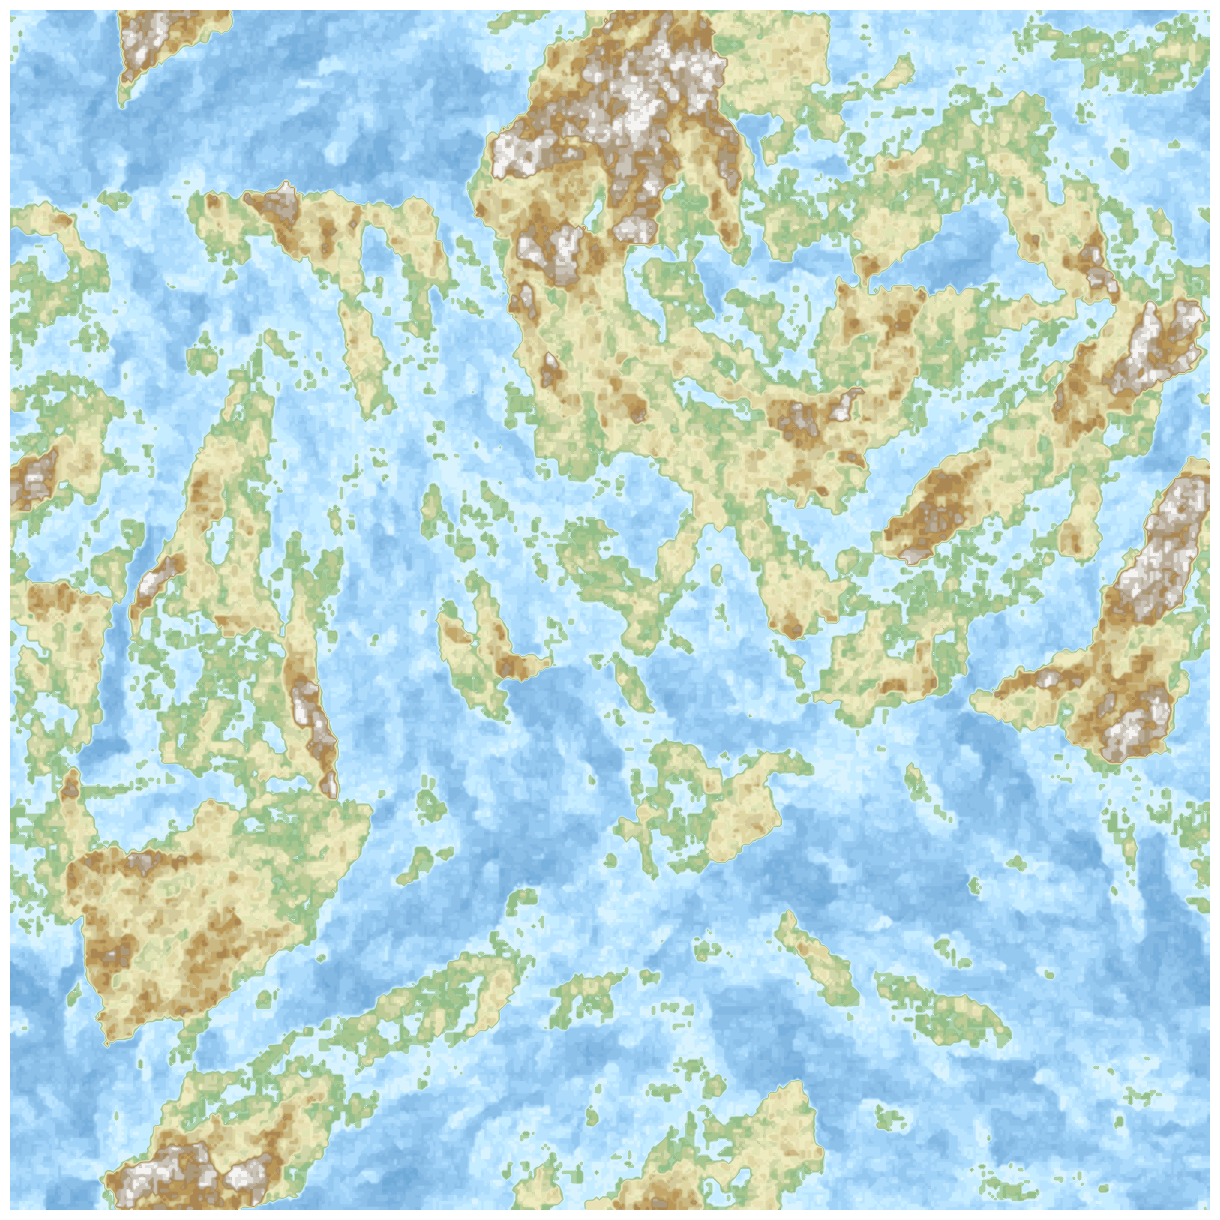

In [8]:
BIG_DIM = 400  # bump further (600+) for even bigger terrain; slower to generate

random.seed(SEED)
big_raw = surface.generate_multi_spark_surface(BIG_DIM, n_walks=3, sparks=100, step=0.1)
big_normalized = palette.normalize_surface(big_raw, n_bins=N_BINS)
big_clean = postprocess.clean_isolated_points(big_normalized)
big_isocurves = postprocess.compute_isocurves(big_clean, n_levels=N_BINS + 8)

fig = render.render_surface(big_clean, rgb_palette, isocurves=big_isocurves)

## 5. Full pipeline via `cli.generate_map`

`cli.generate_map(dim, sparks, step, n_bins, seed)` chains sections 1-4 in
one call — surface -> normalize -> clean -> isocurves — and is what
`python -m brownian_map.cli` runs. No rivers: see section 4.

It uses `generate_brownian_spark_surface` (not the
`generate_multi_spark_surface` fix from section 1), so it's still
susceptible to the single-basin "starburst" pattern if you push `dim` well
past its `300` default.

Run here as a sanity check that it matches the step-by-step run in sections
1-3 (same `DIM`/`SEED`/`N_BINS`).

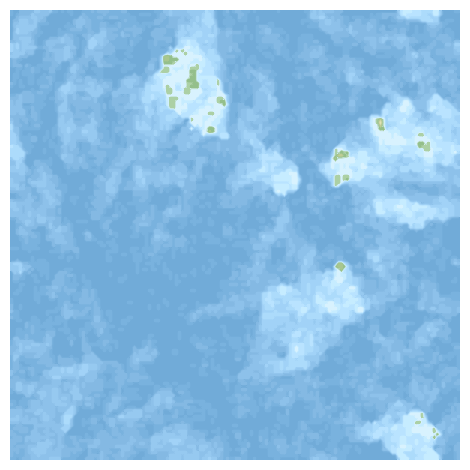

In [9]:
clean2, rgb_palette2, isocurves2 = generate_map(
    dim=DIM,
    sparks=100,
    step=0.1,
    n_bins=N_BINS,
    seed=SEED,
)
fig = render.render_surface(clean2, rgb_palette2, isocurves=isocurves2)

## 6. Parameter sweep playground

Small multiples over `step` (jitter amplitude) and `sparks` (seed-walk
length) — the two params that most change a `generate_brownian_spark_surface`
map's texture. Edit the lists below and re-run to explore. Higher `step`
generally means more land and rougher terrain (see section 1's sweep too);
`sparks` mostly changes how "reach" the seed walk gets before the averaging
fill takes over.

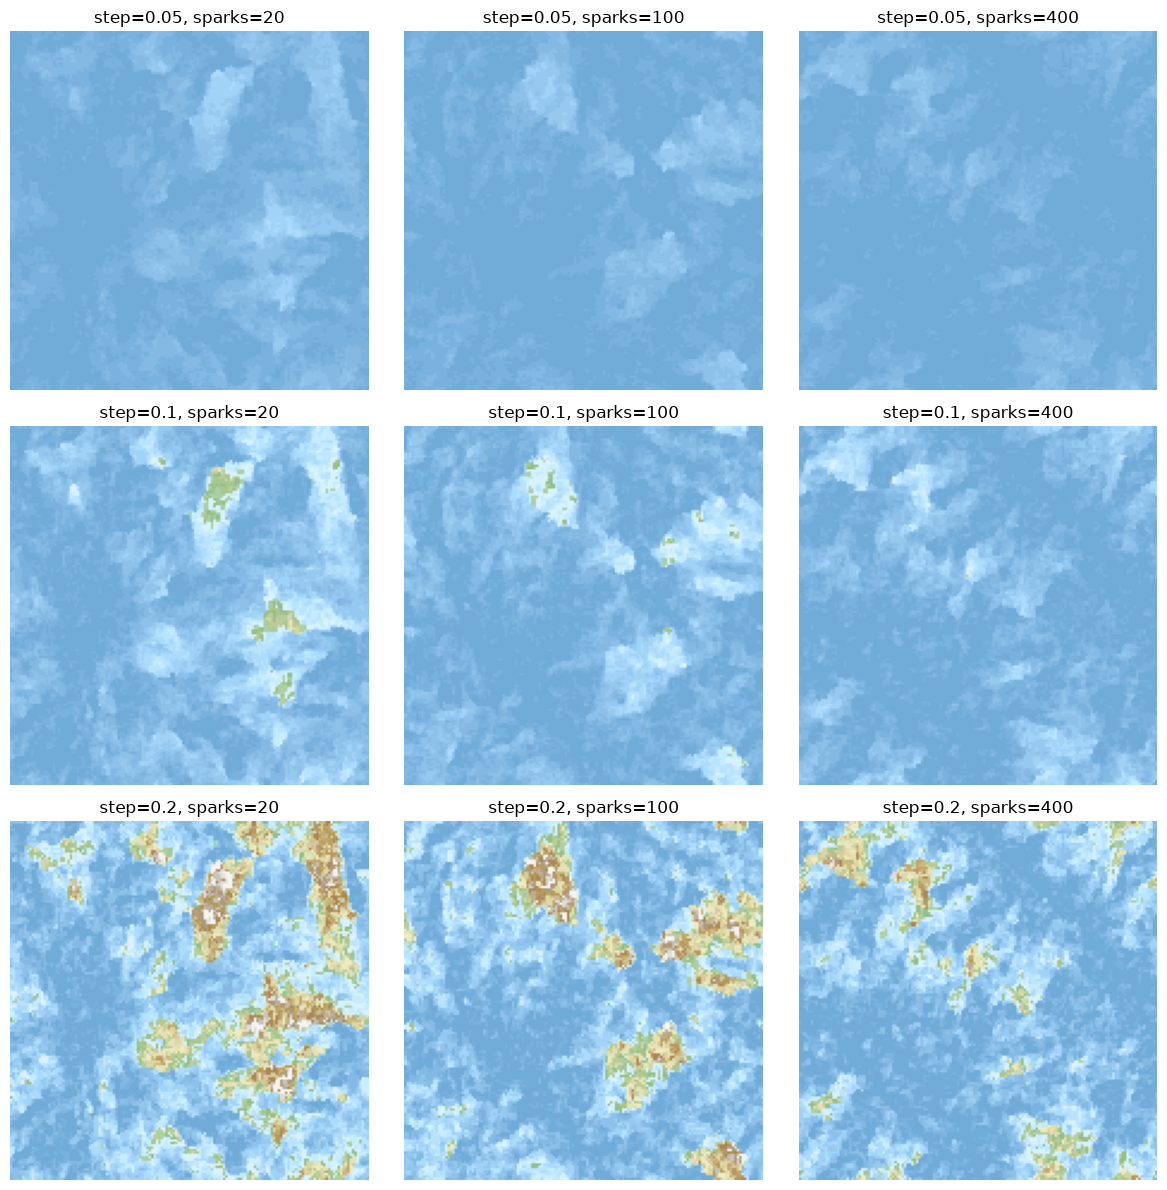

In [10]:
steps = [0.05, 0.1, 0.2]
sparks_list = [20, 100, 400]

fig, axes = plt.subplots(len(steps), len(sparks_list), figsize=(4 * len(sparks_list), 4 * len(steps)))

for i, step in enumerate(steps):
    for j, sparks in enumerate(sparks_list):
        random.seed(SEED)
        srf = surface.generate_brownian_spark_surface(DIM, sparks=sparks, step=step)
        norm = palette.normalize_surface(srf, n_bins=N_BINS)
        norm = postprocess.clean_isolated_points(norm)
        ax = axes[i][j]
        ax.imshow(palette.colorize(norm, rgb_palette))
        ax.set_title(f"step={step}, sparks={sparks}")
        ax.set_axis_off()

fig.tight_layout()

## 7. Full-size render + save

Same `cli.generate_map` call as section 5, at a bigger `dim` and saved to
`docs/map.png` via `render.render_surface`'s `path` argument — that's the
image the README shows, so re-running this cell updates it. Bump `DIM` up
top and re-run from the top instead if you want the bigger size to flow
through every section, not just this one-off render.

wrote docs/map.png


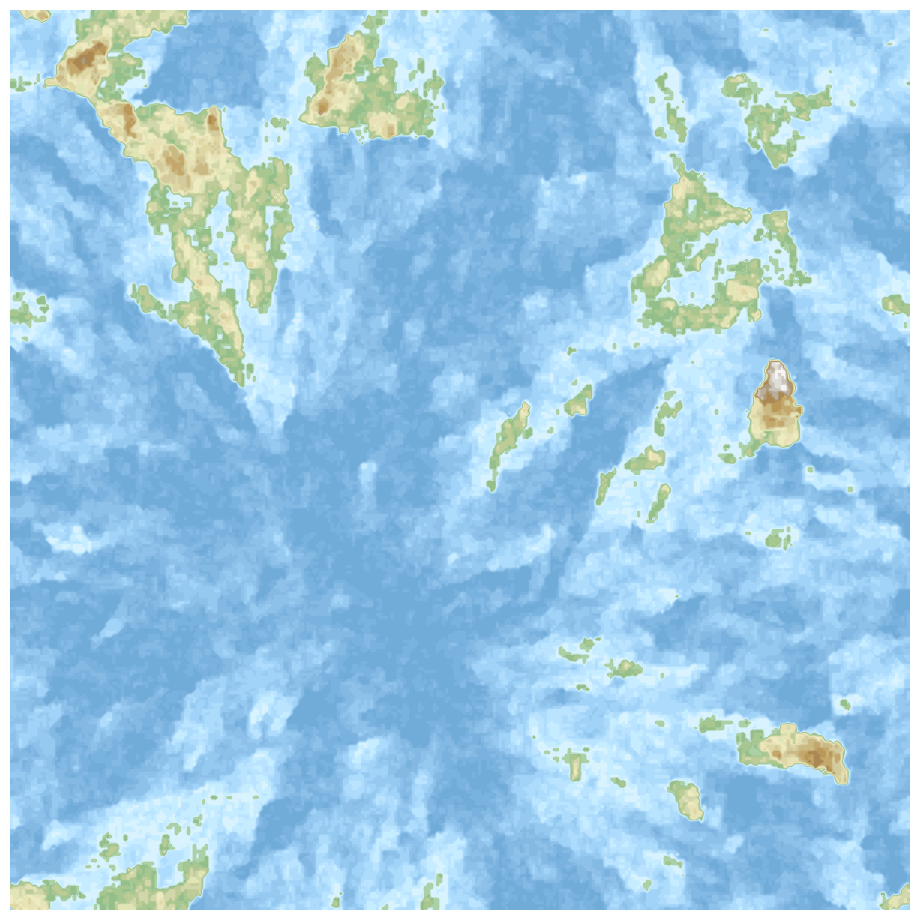

In [11]:
clean_big, rgb_palette_big, isocurves_big = generate_map(
    dim=300,
    sparks=100,
    step=0.1,
    n_bins=20,
    seed=SEED,
)
# docs/map.png is the image the README shows, so re-running this updates it
render.render_surface(clean_big, rgb_palette_big, path="docs/map.png", isocurves=isocurves_big)
print("wrote docs/map.png")